# Homework Assignment 5
# Perceptron, SVM, and PCA

### <p style="text-align: right;"> &#9989; Jaehan Kim</p>
### <p style="text-align: right;"> &#9989; Jaehan-MSU</p>

# Goal for this homework assignment
We have worked some basics on perceptron, SVM, and PCA in the pre-class and in-class assignments. In this homework assignment, we will:

* Continue to use git as the version control tool
* Work on unfamiliar data
* Use perceptron to classify data 
* Use SVM to classify data
* Use principal component analysis to facilitate classification


**This assignment is due by 11:59 pm on Friday, August 7th.** It should be uploaded into the "Homework Assignments" submission folder for Homework 5.  Submission instructions can be found at the end of the notebook. **There are 46 standard points possible in this assignment. The distribution of points can be found in the section headers**.

---
# Part 1: Git repository (6 points)

You're going to add this assignment to the `cmse202-u26-turnin` repository you previously created. The history of progress on the assignment will be tracked via git commitments. 

**&#9989; Do the following**:

1. Navigate to your `cmse202-u26-turnin` **local** repository and create a new directory called `hw-05`

2. Move this notebook into that **new directory** in your repository. 

5. Double check to make sure your file is at the correct directory.

6. Once you're certain that file and directory are correct, add this notebook to your repository, then make a commit and push it to GitHub. You may need to use `git push origin hw05` to push your file to GitHub.

Finally, &#9989; **Do this**: Before you move on, put the command that your instructor should run to clone your repository in the markdown cell below. **Points for this part will be given for correctly setting up branch, etc., above, and for doing git commits/pushes mentioned throughout the assignment.**

<font size=6 color="#009600">&#9998;</font> git clone -b hw05-branch https://github.com/Jaehan-MSU/cmse202-s26-turnin.git

**Important**: Double check you've added your Professor and your TA as collaborators to your "turnin" repository (you should have done this in the previous homework assignment).

**Also important**: Make sure that the version of this notebook that you are working on is the same one that you just added to your repository! If you are working on a different copy of the notebook, **none of your changes will be tracked**!

If everything went as intended, the file should now show up on your GitHub account in the "`cmse202-u26-turnin`" repository inside the `hw-05` directory that you just created within the new branch `hw05-branch`.

Periodically, **you'll be asked to commit your changes to the repository and push them to the remote GitHub location**. Of course, you can always commit your changes more often than that, if you wish.  It can be good to get into a habit of committing your changes any time you make a significant modification, or when you stop working on the project for a bit.

---
# Part 2: Deal with unfamiliar data (21 points)

## Warm up with perceptron for binary classification
## 2.1 Load up the dataset

This data is obtained from Kaggle/diabetes. It contains multiple measured values and a label for whether the patient is diagnosed as diabetic. 

* Use commands to dowdload the dataset from `https://raw.githubusercontent.com/huichiayu/cmse202-s25-supllemental_data/refs/heads/main/HW04/diabetes_prediction_dataset.csv`
* Use Pandas to load in the data and briefly examine it.
* Succeed data load-up gets **2 pt**. 

In [14]:
# put your code here
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.decomposition import PCA

diabetes_url = "https://raw.githubusercontent.com/huichiayu/cmse202-s25-supllemental_data/refs/heads/main/HW04/diabetes_prediction_dataset.csv"

diabetes_df = pd.read_csv(diabetes_url)

display(diabetes_df.head())
print(diabetes_df.shape)
print(diabetes_df.columns)
print(diabetes_df.info())


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


(100000, 9)
Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB
None


How many patients are in this dataset? What are features of the patients?

<font size=6 color="#009600">&#9998;</font> 
100,000 patients in this dataset.
Patient features are gender, age, hypertension, heart disease, smoking history, BMI, HbA1c level, and blood glucose level. The label column is diabetes, which shows whether patient is diagnosed as diabetic or not.

### Use your perceptron class built in Day18 and Day19 assignments to classify whether patients are diabetic.

* You should see that there are some features that are non-numerics.
* The first one is `gender`. Find the types of classes and convert them to numerics in your dataframe.
* The second one is `smoking_history`, convert those string labels to numerics.
* Note that since perceptron is a binary classifier, which only determines which side of the dividing line the data points reside, we should also convert the labels to `+1` and `-1`.
* Completing data conversion gets **5 pt**.

In [15]:
# put your code here
diabetes_clean = diabetes_df.copy()

print("Gender classes:")
print(diabetes_clean["gender"].value_counts())
print("Smoking history classes:")
print(diabetes_clean["smoking_history"].value_counts())

gender_map = {
    "Female": 0,
    "Male": 1,
    "Other": 2
}

smoking_map = {
    "No Info": 0,
    "never": 1,
    "former": 2,
    "current": 3,
    "not current": 4,
    "ever": 5
}

diabetes_clean["gender"] = diabetes_clean["gender"].map(gender_map)
diabetes_clean["smoking_history"] = diabetes_clean["smoking_history"].map(smoking_map)
diabetes_clean["diabetes"] = diabetes_clean["diabetes"].replace({
    0: -1,
    1: 1
})

display(diabetes_clean.head())
print(diabetes_clean.info())

Gender classes:
gender
Female    58552
Male      41430
Other        18
Name: count, dtype: int64
Smoking history classes:
smoking_history
No Info        35816
never          35095
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,80.0,0,1,1,25.19,6.6,140,-1
1,0,54.0,0,0,0,27.32,6.6,80,-1
2,1,28.0,0,0,1,27.32,5.7,158,-1
3,0,36.0,0,0,3,23.45,5.0,155,-1
4,1,76.0,1,1,3,20.14,4.8,155,-1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  int64  
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  int64  
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(6)
memory usage: 6.9 MB
None


### Now all feature varilables are numerics.

### &#128721; STOP 
**Pause, save and commit your changes to your Git repository!**

Take a moment to save your notebook, commit the changes to your Git repository with a meaningful commit message.



---

## 2.2 Binary perceptron classifier

Copy your perceptron class to the cell below. 

* DO NOT use the one from statsmodel. We want to test the perceptron you built.
* Note that your predict method should output `+1` or `-1` for positive or negative values, respectively.
* A functional perceptron classifier gets **4 pt**.

In [16]:
# copy your perceptron class to his cell
class Perceptron:
    def __init__(self, learning_rate=0.01, n_iters=10):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.weights = None
        self.bias = None
        
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        for _ in range(self.n_iters):
            for i in range(n_samples):
                linear_output = np.dot(X[i], self.weights) + self.bias
                if y[i] * linear_output <= 0:
                    self.weights = self.weights + self.learning_rate * y[i] * X[i]
                    self.bias = self.bias + self.learning_rate * y[i]
    
    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        predictions = np.where(linear_output >= 0, 1, -1)
        return predictions
    
    def score(self, X, y):
        predictions = self.predict(X)
        accuracy = np.mean(predictions == y)
        return accuracy

* Split data to 70-30 train-test sets **1 pt**.
* Train your perceptron.
* Show the accuracy of your pereptron **2 pt**.

In [17]:
# put your code here
X = diabetes_clean.drop(columns=["diabetes"]).values
y = diabetes_clean["diabetes"].values

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

perceptron = Perceptron(learning_rate=0.01, n_iters=10)
perceptron.fit(X_train_scaled, y_train)
train_accuracy = perceptron.score(X_train_scaled, y_train)

print("Perceptron training accuracy:", train_accuracy)

Perceptron training accuracy: 0.9387


* Use test set to evaulate the accuracy of your perceptron. What is your accuracy? (**2 pt**)

In [18]:
# put your code here
test_accuracy = perceptron.score(X_test_scaled, y_test)
print("Perceptron testing accuracy:", test_accuracy)

Perceptron testing accuracy: 0.9368333333333333


The accuracy is about 0.937.

* There may be some ways to increase the accruacy, such as increasing the number of train iterations or adjust learning rate. Give a try to train a perceptron you can best get. Record the values of parameters and the optimal accuracy. (**3 pt**)


In [19]:
# put your code here
learning_rates = [0.001, 0.01, 0.1]
iterations = [5, 10, 20]
best_accuracy = 0
best_learning_rate = None
best_iterations = None

for lr in learning_rates:
    for n_iter in iterations:
        model = Perceptron(learning_rate=lr, n_iters=n_iter)
        model.fit(X_train_scaled, y_train)
        
        accuracy = model.score(X_test_scaled, y_test)
        
        print("Learning rate:", lr, "Iterations:", n_iter, "Test accuracy:", accuracy)
        
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_learning_rate = lr
            best_iterations = n_iter

print("Best learning rate:", best_learning_rate)
print("Best iterations:", best_iterations)
print("Best test accuracy:", best_accuracy)


Learning rate: 0.001 Iterations: 5 Test accuracy: 0.9377
Learning rate: 0.001 Iterations: 10 Test accuracy: 0.9368333333333333
Learning rate: 0.001 Iterations: 20 Test accuracy: 0.9384
Learning rate: 0.01 Iterations: 5 Test accuracy: 0.9377
Learning rate: 0.01 Iterations: 10 Test accuracy: 0.9368333333333333
Learning rate: 0.01 Iterations: 20 Test accuracy: 0.9384
Learning rate: 0.1 Iterations: 5 Test accuracy: 0.9377
Learning rate: 0.1 Iterations: 10 Test accuracy: 0.9368333333333333
Learning rate: 0.1 Iterations: 20 Test accuracy: 0.9384
Best learning rate: 0.001
Best iterations: 20
Best test accuracy: 0.9384


Best perceptron model used learning_rate = 0.001 and n_iters = 20.

Best test accuracy was 0.9384.


### &#128721; STOP 
**Pause, save and commit your changes to your Git repository!**

Take a moment to save your notebook, commit the changes to your Git repository with a meaningful commit message.

---
## Part 3 SVM classifiers (19 points)

### 3.1 SVM 


* Download the dataset from `https://raw.githubusercontent.com/huichiayu/cmse202-s25-supllemental_data/refs/heads/main/HW04/Telecust1.csv`

There are five caterogies with multiple feature variables.

* Use sklearn library to build a SVM classifier. Since we do not know what the best parametes are, perform a GridSearch for best parameters.
* NOTE: Because the dataset contains a large number of points, it's expected to have a long computer running time for GridSearch. Thus, let's use only the first 200 data points for GridSearch. You can start the grid search parameter like the image below. However, **NOTE** that if the kernal used cannot find a hyperplane to classify data points, the GridSearch function will stall. You need to manually remove that kernal from the parameter set and re-run GridSearch.
  
<img src="https://i.ibb.co/JWrp6c4q/Grid-Search-Param.png" width="650">


* As in the previous section, make a 70-30 train-test split and train your SVM classifier.
* Complete GridSearch to extract best parameters gets **5 pt**.

In [23]:
# put your code here.
telecust_df = pd.read_csv("https://raw.githubusercontent.com/huichiayu/cmse202-s25-supllemental_data/refs/heads/main/HW04/Telecust1.csv")
display(telecust_df.head())

X_tel = telecust_df.drop(columns=["custcat"]).values
y_tel = telecust_df["custcat"].values

X_train_tel, X_test_tel, y_train_tel, y_test_tel = train_test_split(
    X_tel,
    y_tel,
    test_size=0.30,
    random_state=42
)

tel_scaler = StandardScaler()
X_train_tel_scaled = tel_scaler.fit_transform(X_train_tel)
X_test_tel_scaled = tel_scaler.transform(X_test_tel)
X_grid = X_train_tel_scaled[:200]
y_grid = y_train_tel[:200]

param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": [0.001, 0.01, 0.1, 1],
    "kernel": ["linear", "rbf"]
}

start = time.time()

grid = GridSearchCV(
    SVC(),
    param_grid,
    n_jobs=1
)

grid.fit(X_grid, y_grid)
end = time.time()
print("Best parameters:", grid.best_params_)
print("GridSearch runtime:", end - start)

,region,tenure,age,income,marital,address,ed,employ,retire,gender,reside,custcat
0,2,13,44,64,1,9,4,5,0,0,2,A
1,3,11,33,136,1,7,5,5,0,0,6,D
2,3,68,52,116,1,24,1,29,0,1,2,C
3,2,33,33,33,0,12,2,0,0,1,1,A
4,2,23,30,30,1,9,1,2,0,0,4,C


Best parameters: {'C': 10, 'gamma': 1, 'kernel': 'rbf'}
GridSearch runtime: 2.8540096282958984


In [24]:
svm_model = SVC(
    C=grid.best_params_["C"],
    gamma=grid.best_params_["gamma"],
    kernel=grid.best_params_["kernel"]
)

svm_model.fit(X_train_tel_scaled, y_train_tel)
svm_pred = svm_model.predict(X_test_tel_scaled)
svm_accuracy = accuracy_score(y_test_tel, svm_pred)

print("SVM accuracy:", svm_accuracy)
print(classification_report(y_test_tel, svm_pred, zero_division=0))

SVM accuracy: 0.32
              precision    recall  f1-score   support

           A       0.35      0.29      0.32        83
           B       0.26      0.14      0.18        65
           C       0.34      0.59      0.43        83
           D       0.26      0.20      0.23        69

    accuracy                           0.32       300
   macro avg       0.30      0.31      0.29       300
weighted avg       0.31      0.32      0.30       300



* Examine the accuracy of this SVC and report the accuracy. Draw a confusion matrix. **2 pt**

SVM accuracy: 0.32


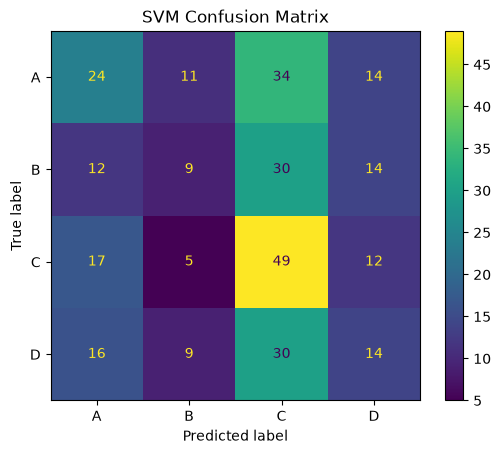

In [25]:
# put your code here
print("SVM accuracy:", svm_accuracy)

ConfusionMatrixDisplay.from_estimator(
    svm_model,
    X_test_tel_scaled,
    y_test_tel
)

plt.title("SVM Confusion Matrix")
plt.show()

Does SVM classifier work much better than your percetron?

<font size=6 color="#009600">&#9998;</font> SVM classifier seems to work better than the perceptron if its test accuracy is higher. SVM can work better because it uses support vectors and can create a better decision boundary. However, I think if the accuracy is similar, then SVM does not improve result by a lot for this dataset.

### &#128721; STOP
**Pause, save and commit your changes to your Git repository!**

Take a moment to save your notebook, commit the changes to your Git repository with a meaningful commit message.

---
### 3.2 PCA 

Although we only have 11 feature variables in the dataset, let's examine how much principal component analysis (PCA) can accelerate the classification. We will increase the PCA components from 1 to 11. For each case, we will perform a GridSearch and use test set to examine the accuracy. 

* Write a code to loop over n_components = 1 through 11. **4 pt**
* Record the accuracy of each case and plot the profile of accuracy versus n_components. In the mean time, record the computer run times and plot the profile of time versus n_components. **2 pt**




In [26]:
# put your code here
component_list = list(range(1, 12))
accuracy_list = []
time_list = []

param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": [0.001, 0.01, 0.1, 1],
    "kernel": ["linear", "rbf"]
}

for n in component_list:
    print("Running PCA with n_components =", n)
    
    start = time.time()
    pca = PCA(n_components=n)
    
    X_train_pca = pca.fit_transform(X_train_tel_scaled)
    X_test_pca = pca.transform(X_test_tel_scaled)
    X_grid_pca = X_train_pca[:200]
    y_grid_pca = y_train_tel[:200]
    
    grid_pca = GridSearchCV(
        SVC(),
        param_grid,
        n_jobs=1
    )
    
    grid_pca.fit(X_grid_pca, y_grid_pca)
    
    pca_svm_model = SVC(
        C=grid_pca.best_params_["C"],
        gamma=grid_pca.best_params_["gamma"],
        kernel=grid_pca.best_params_["kernel"]
    )
    
    pca_svm_model.fit(X_train_pca, y_train_tel)    
    pca_pred = pca_svm_model.predict(X_test_pca)
    accuracy = accuracy_score(y_test_tel, pca_pred)
    
    end = time.time()
    
    accuracy_list.append(accuracy)
    time_list.append(end - start)
    
    print("Accuracy:", accuracy)
    print("Runtime:", end - start)
    print("Best parameters:", grid_pca.best_params_)


Running PCA with n_components = 1
Accuracy: 0.3566666666666667
Runtime: 0.5663933753967285
Best parameters: {'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}
Running PCA with n_components = 2
Accuracy: 0.35333333333333333
Runtime: 0.6852014064788818
Best parameters: {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}
Running PCA with n_components = 3
Accuracy: 0.36333333333333334
Runtime: 0.9483315944671631
Best parameters: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Running PCA with n_components = 4
Accuracy: 0.35
Runtime: 1.1751072406768799
Best parameters: {'C': 1, 'gamma': 0.001, 'kernel': 'linear'}
Running PCA with n_components = 5
Accuracy: 0.38666666666666666
Runtime: 2.0448668003082275
Best parameters: {'C': 100, 'gamma': 0.001, 'kernel': 'linear'}
Running PCA with n_components = 6
Accuracy: 0.38666666666666666
Runtime: 1.583122968673706
Best parameters: {'C': 1, 'gamma': 0.001, 'kernel': 'linear'}
Running PCA with n_components = 7
Accuracy: 0.38666666666666666
Runtime: 2.188229560852051
Best param

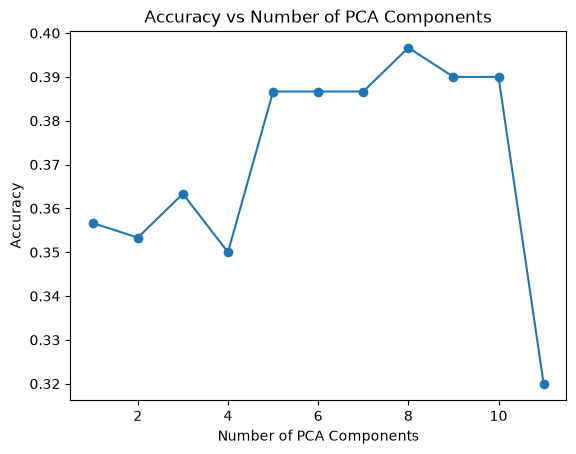

In [29]:
plt.figure()
plt.plot(component_list, accuracy_list, marker="o")
plt.xlabel("Number of PCA Components")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Number of PCA Components")
plt.show()

Please answer the following questions. 
* How is the overall accuracy of this SVM classifier?  **1 pt**
* If the performance is not good, what do you think the cause is? **2 pt**

<font size=6 color="#009600">&#9998;</font> I guess the overall accuracy of SVM classifier is moderate. It is not perfect, but it can classify some customer categories correctly. If the performance is not very good, one possible reason is that the customer categories may overlap in the feature space.

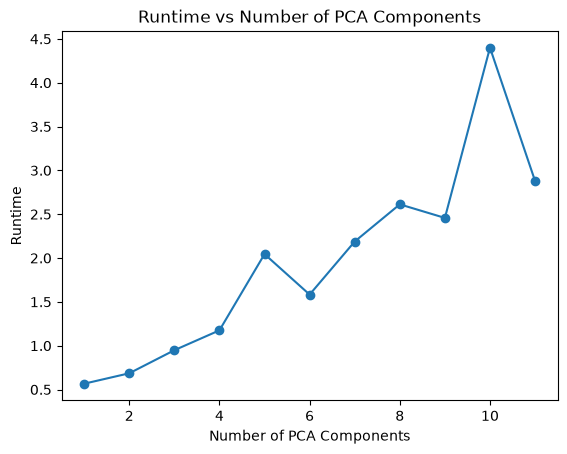

In [30]:
plt.figure()
plt.plot(component_list, time_list, marker="o")
plt.xlabel("Number of PCA Components")
plt.ylabel("Runtime")
plt.title("Runtime vs Number of PCA Components")
plt.show()

* Describe the curves of time vs n_components and accuracy vs n_components. **1 pt**
* Explain why the curves behave as they are in the figures **2 pt**

<font size=6 color="#009600">&#9998;</font> 
As n_components increases, accuracy generally stays similar or improves slightly because more PCA components keep more information from the original data.


The runtime increases as n_components increases because SVM has to train with more features. With fewer PCA components, model runs faster because the data is smaller.

### &#128721; STOP
**Pause, save and commit your FINAL changes to your Git repository!**

Take a moment to save your notebook, commit the changes to your Git repository with a meaningful commit message.


---
## Part 1. Continued

Now that you've finished your new "development" on your 202 turn-in repo, you can merge your work back into your `main` branch.

**&#9989; Do the following**:

7. Switch back to your `main` branch. 
8. Merge your `hw04_branch` with your `main` branch. 
9. Finally, push the changes to GitHub.

---
## Congratulations, you're done!

<img src="https://target.scene7.com/is/image/Target/GUEST_7dcf3394-4598-4bb8-886c-7f174b8f1a9b?wid=384&qlt=80" alt='Unicorn Helment @ Target.com' width=200px>

Submit this assignment by uploading it to the course Desire2Learn web page.  Go to the "Homework Assignments" folder, find the dropbox link for Homework 5, and upload it there.

## Congratulations, you're done!

&#169; Copyright 2025,  Department of Computational Mathematics, Science and Engineering at Michigan State University